## Introduction

This project analyzes global COVID-19 data to extract meaningful insights using data visualization techniques.

The dataset includes confirmed cases, deaths, recoveries, and geographic information across different countries and dates.

### Objectives:
- Understand the global spread of COVID-19 over time
- Identify most affected countries
- Analyze recovery vs death trends
- Extract meaningful insights using visualization

In [34]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/covid_19_clean_complete.csv')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


## Data Cleaning

We performed the following steps:
- Converted Date column to datetime format
- Handled missing values by filling with 0
- Update Active cases based on Confirmed, Deaths, and Recovered
- Aggregated data at country level to avoid duplication from provinces

In [18]:
df['Date'] = pd.to_datetime(df['Date'])

df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [19]:
df.fillna(0, inplace=True)

In [20]:
df['Active'] = df['Confirmed'] - df['Deaths'] - df['Recovered']

In [21]:
df_country = df.groupby(['Country/Region', 'Date'], as_index=False).agg({
    'Confirmed': 'sum',
    'Deaths': 'sum',
    'Recovered': 'sum'
})

In [22]:
df_country['Active'] = df_country['Confirmed'] - df_country['Deaths'] - df_country['Recovered']

In [23]:
df_country.head()

,Country/Region,Date,Confirmed,Deaths,Recovered,Active
0,Afghanistan,2020-01-22,0,0,0,0
1,Afghanistan,2020-01-23,0,0,0,0
2,Afghanistan,2020-01-24,0,0,0,0
3,Afghanistan,2020-01-25,0,0,0,0
4,Afghanistan,2020-01-26,0,0,0,0


### Key Insights:
We observe a sharp increase in confirmed cases during the early months, followed by a gradual stabilization.
Recovery cases started increasing significantly after the peak period, indicating improved treatment and healthcare response.

In [24]:
global_trend = df_country.groupby('Date')[['Confirmed','Deaths','Recovered']].sum().reset_index()
global_trend.head()

,Date,Confirmed,Deaths,Recovered
0,2020-01-22,555,17,28
1,2020-01-23,654,18,30
2,2020-01-24,941,26,36
3,2020-01-25,1434,42,39
4,2020-01-26,2118,56,52


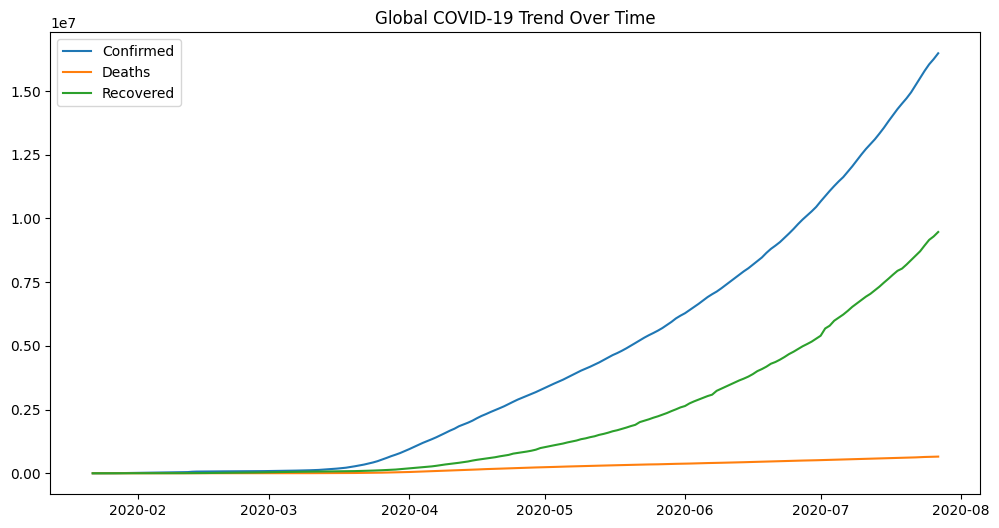

In [25]:
plt.figure(figsize=(12,6))
plt.plot(global_trend['Date'], global_trend['Confirmed'], label='Confirmed')
plt.plot(global_trend['Date'], global_trend['Deaths'], label='Deaths')
plt.plot(global_trend['Date'], global_trend['Recovered'], label='Recovered')

plt.title("Global COVID-19 Trend Over Time")
plt.legend()

plt.show()

### Key Insights:
A small number of countries dominate global case counts, indicating uneven spread and impact of the pandemic.

In [26]:
latest = df_country[df_country['Date'] == df_country['Date'].max()]

In [27]:
latest.head()

,Country/Region,Date,Confirmed,Deaths,Recovered,Active
187,Afghanistan,2020-07-27,36263,1269,25198,9796
375,Albania,2020-07-27,4880,144,2745,1991
563,Algeria,2020-07-27,27973,1163,18837,7973
751,Andorra,2020-07-27,907,52,803,52
939,Angola,2020-07-27,950,41,242,667


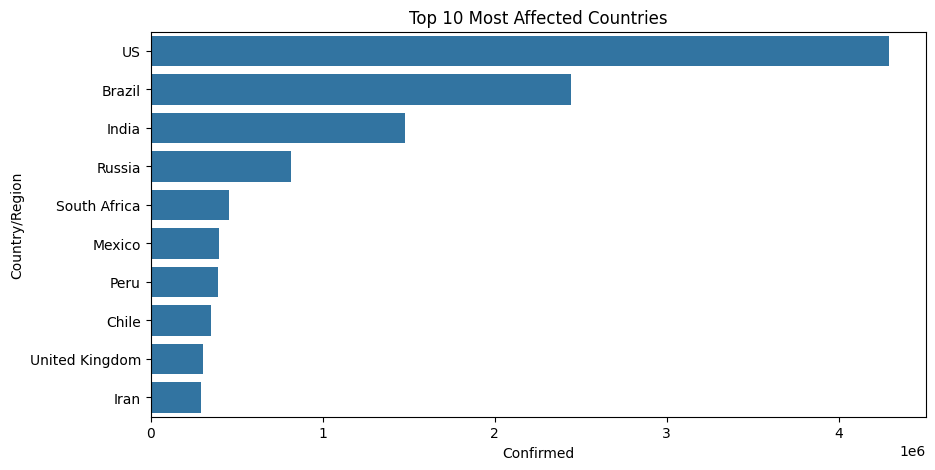

In [28]:
top_countries = latest.sort_values(by='Confirmed', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x='Confirmed', y='Country/Region', data=top_countries)

plt.title("Top 10 Most Affected Countries")
plt.show()

### Key Insights:
Recovery rates are generally higher than death rates, but significant variation exists between countries, reflecting differences in healthcare systems.

In [29]:
latest = df_country[df_country['Date'] == df_country['Date'].max()].copy()

latest['Death_Rate'] = latest['Deaths'] / latest['Confirmed']
latest['Recovery_Rate'] = latest['Recovered'] / latest['Confirmed']

latest.head()

,Country/Region,Date,Confirmed,Deaths,Recovered,Active,Death_Rate,Recovery_Rate
187,Afghanistan,2020-07-27,36263,1269,25198,9796,0.034994,0.694868
375,Albania,2020-07-27,4880,144,2745,1991,0.029508,0.562500
563,Algeria,2020-07-27,27973,1163,18837,7973,0.041576,0.673399
751,Andorra,2020-07-27,907,52,803,52,0.057332,0.885336
939,Angola,2020-07-27,950,41,242,667,0.043158,0.254737


In [30]:
top_rates = latest.sort_values(by='Confirmed', ascending=False).head(10)

top_rates[['Country/Region','Death_Rate','Recovery_Rate']]

,Country/Region,Death_Rate,Recovery_Rate
32711,US,0.034499,0.309027
4511,Brazil,0.035874,0.756084
15039,India,0.022572,0.642648
26131,Russia,0.016327,0.737436
29139,South Africa,0.015617,0.607530
21055,Mexico,0.111310,0.768188
25003,Peru,0.047260,0.699346
6767,Chile,0.026405,0.919612
33463,United Kingdom,0.151948,0.004763
15415,Iran,0.054195,0.869001


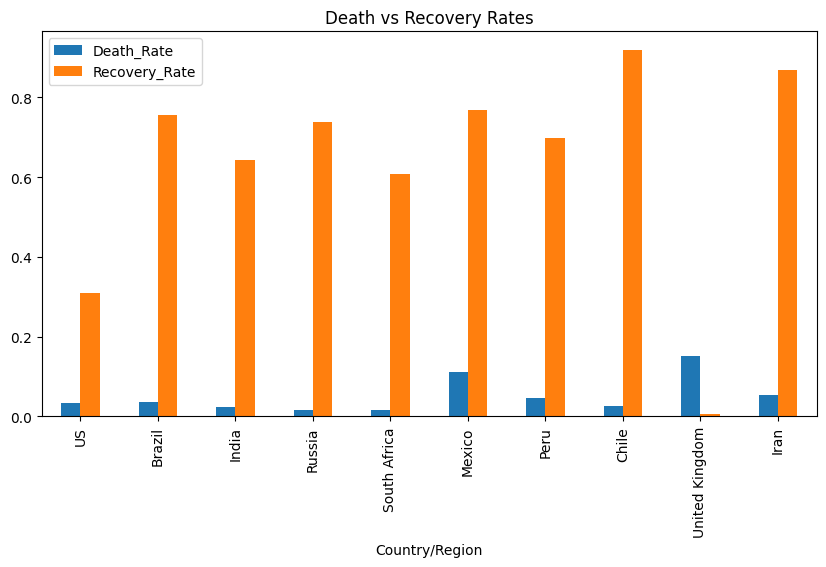

In [31]:
top_rates.set_index('Country/Region')[['Death_Rate','Recovery_Rate']].plot(kind='bar', figsize=(10,5))

plt.title("Death vs Recovery Rates")
plt.show()

### Key Insights:
Countries with higher confirmed cases tend to have higher recoveries, but the size of deaths varies, indicating differences in pandemic management.

In [32]:
filtered = latest[latest['Confirmed'] > 100000]
filtered.head()

,Country/Region,Date,Confirmed,Deaths,Recovered,Active,Death_Rate,Recovery_Rate
1315,Argentina,2020-07-27,167416,3059,72575,91782,0.018272,0.433501
2631,Bangladesh,2020-07-27,226225,2965,125683,97577,0.013106,0.555566
4511,Brazil,2020-07-27,2442375,87618,1846641,508116,0.035874,0.756084
6203,Canada,2020-07-27,116458,8944,0,107514,0.076800,0.000000
6767,Chile,2020-07-27,347923,9187,319954,18782,0.026405,0.919612


In [35]:
fig = px.scatter(
    filtered,
    x='Confirmed',
    y='Recovered',
    size='Deaths',
    color='Country/Region',
    hover_name='Country/Region',
    title="Confirmed vs Recovered Cases"
)

fig.show()

### Key Insights:
Active cases show waves of increase and decrease, reflecting pandemic waves across different time periods.

In [36]:
active_trend = df.groupby('Date')['Active'].sum()
active_trend.head()

,Active
Date,
2020-01-22,510
2020-01-23,606
2020-01-24,879
2020-01-25,1353
2020-01-26,2010


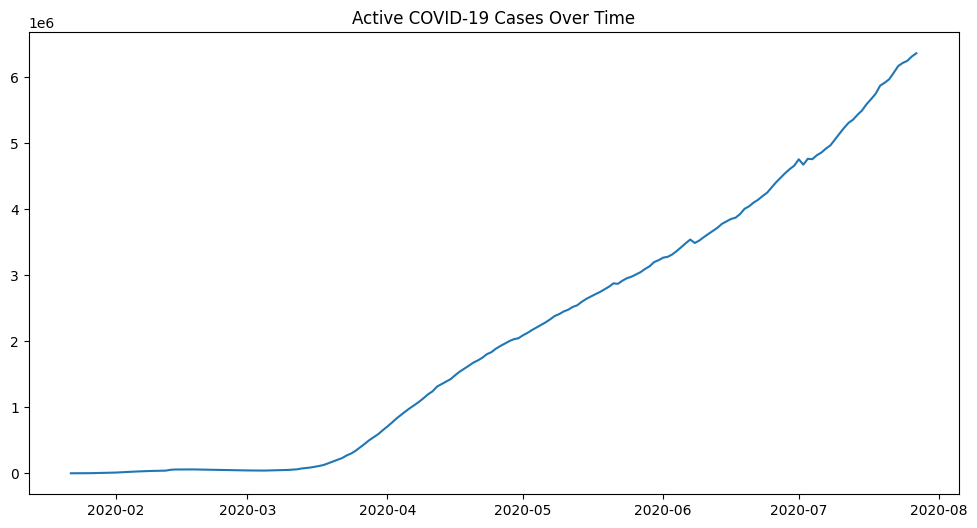

In [37]:
plt.figure(figsize=(12,6))
plt.plot(active_trend.index, active_trend.values)

plt.title("Active COVID-19 Cases Over Time")
plt.show()

## Conclusion

From this analysis, we conclude:

- COVID-19 spread globally with different intensities across countries.
- Some countries were significantly more affected than others.
- Recovery trends improved over time, indicating better healthcare response.
- The pandemic evolved in waves rather than a single continuous rise.
- Additional metrics such as death and recovery rates provided deeper insight into healthcare effectiveness.

This visualization-based analysis helps in understanding the overall behavior of the pandemic and supports data-driven decision making.